# Power of Data Communities - v2 Analysis

**Revised analysis addressing PLOS Digital Health editor feedback**

This notebook provides a reproducible analysis of citation patterns for open medical data communities, with improvements in:

1. **Data Source**: OpenAlex API (replacing manual Google Scholar)
2. **Longevity Adjustment**: Enhanced metrics accounting for dataset age
3. **Funding Attribution**: Documented sources with currency standardization
4. **Consent & Reidentifiability**: New comparative analysis
5. **Statistical Rigor**: Confidence intervals and significance tests

---

## 1. Setup & Data Loading

In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from datetime import datetime

# Configure plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paths
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Analysis parameters
CURRENT_YEAR = 2025
ANALYSIS_DATE = datetime.now().strftime('%Y-%m-%d')

print(f"Analysis date: {ANALYSIS_DATE}")
print(f"Current year for analysis: {CURRENT_YEAR}")

Analysis date: 2026-01-27
Current year for analysis: 2025


In [2]:
# Load dataset metadata
metadata_df = pd.read_csv(DATA_DIR / 'datasets_metadata.csv')
print(f"Loaded metadata for {len(metadata_df)} datasets")
metadata_df[['dataset', 'launch_year', 'funding_usd', 'consent_model', 'access_model']]

Loaded metadata for 4 datasets


,dataset,launch_year,funding_usd,consent_model,access_model
0,All-MIMIC,2003,14427192,IRB waiver,Open (credentialed)
1,UK-Biobank,2012,525546276,Broad informed consent,Controlled access
2,OpenSAFELY,2020,53715055,NHS data governance,Trusted Research Environment
3,All-of-Us,2018,2160000000,Tiered informed consent,Controlled tiers


In [3]:
# Load combined citation data and aggregate MIMIC versions
try:
    citations_raw = pd.read_csv(DATA_DIR / 'all_citations_combined.csv')
    print(f"Loaded {len(citations_raw)} raw citation records")
    
    # Filter to CURRENT_YEAR and earlier (exclude partial 2026 data)
    citations_raw = citations_raw[citations_raw['year'] <= CURRENT_YEAR]
    print(f"After filtering to <= {CURRENT_YEAR}: {len(citations_raw)} records")
    
    # Combine MIMIC-I, II, III, IV into "All-MIMIC"
    mimic_datasets = ['MIMIC-I', 'MIMIC-II', 'MIMIC-III', 'MIMIC-IV']
    mimic_df = citations_raw[citations_raw['dataset'].isin(mimic_datasets)].copy()
    other_df = citations_raw[~citations_raw['dataset'].isin(mimic_datasets)].copy()
    
    # Aggregate MIMIC by year (sum citations across all MIMIC versions)
    mimic_combined = mimic_df.groupby('year').agg({
        'citation_count': 'sum',
    }).reset_index()
    mimic_combined['cumulative_citations'] = mimic_combined['citation_count'].cumsum()
    mimic_combined['dataset'] = 'All-MIMIC'
    mimic_combined['doi'] = 'multiple'
    mimic_combined['openalex_id'] = 'combined'
    
    # Recalculate cumulative for other datasets after filtering
    for dataset in other_df['dataset'].unique():
        mask = other_df['dataset'] == dataset
        other_df.loc[mask, 'cumulative_citations'] = other_df.loc[mask, 'citation_count'].cumsum()
    
    # Combine with other datasets
    citations_df = pd.concat([
        mimic_combined[['year', 'citation_count', 'cumulative_citations', 'dataset', 'doi', 'openalex_id']],
        other_df[['year', 'citation_count', 'cumulative_citations', 'dataset', 'doi', 'openalex_id']]
    ], ignore_index=True)
    
    print(f"After combining MIMIC versions: {len(citations_df)} records")
    print(f"Datasets: {citations_df['dataset'].unique()}")
    print(f"Year range: {citations_df['year'].min()} - {citations_df['year'].max()}")
    
    # Show MIMIC totals
    mimic_total = mimic_combined['cumulative_citations'].max()
    print(f"\nAll-MIMIC combined citations (through {CURRENT_YEAR}): {mimic_total:,}")
except FileNotFoundError:
    print("Citation data not found. Run scripts/fetch_citations.py first.")
    citations_df = None

Loaded 77 raw citation records
After filtering to <= 2025: 72 records
After combining MIMIC versions: 43 records
Datasets: ['All-MIMIC' 'OpenSAFELY' 'UK-Biobank' 'All-of-Us']
Year range: 2012 - 2025

All-MIMIC combined citations (through 2025): 10,034


---
## 2. Citation Analysis

Basic citation trends over time for each dataset.

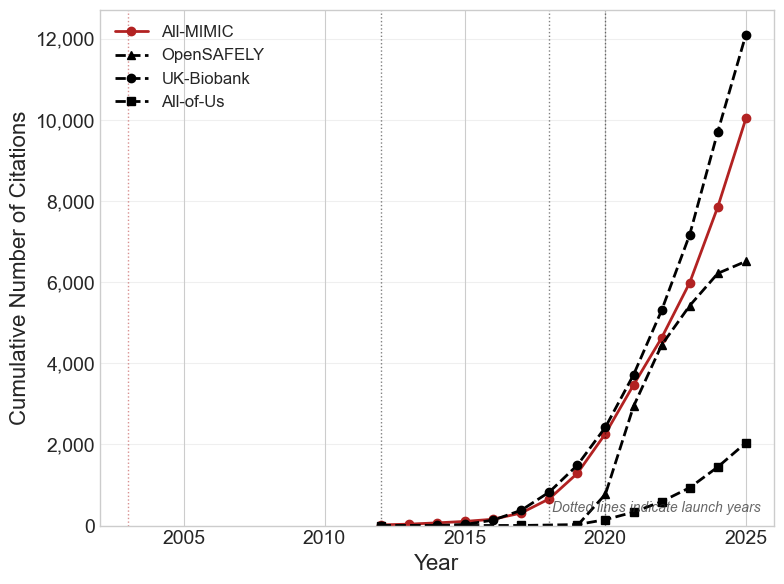

In [4]:
# Plot cumulative citations over time (matching original style with markers and x-axis from 2003)
if citations_df is not None:
    # Filter to 2025 and earlier
    plot_data = citations_df[citations_df['year'] <= 2025].copy()
    
    # Configure font to match original
    plt.rcParams['font.sans-serif'] = 'Arial'
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Define colors and markers for each dataset (similar to original)
    styles = {
        'All-MIMIC': {'color': 'firebrick', 'marker': 'o', 'linestyle': '-'},
        'UK-Biobank': {'color': 'black', 'marker': 'o', 'linestyle': '--'},
        'OpenSAFELY': {'color': 'black', 'marker': '^', 'linestyle': '--'},
        'All-of-Us': {'color': 'black', 'marker': 's', 'linestyle': '--'}
    }
    
    # Get launch years from metadata
    launch_years = metadata_df.set_index('dataset')['launch_year'].to_dict()
    
    # Plot each dataset
    for dataset in plot_data['dataset'].unique():
        df = plot_data[plot_data['dataset'] == dataset].sort_values('year')
        style = styles.get(dataset, {'color': 'gray', 'marker': 'o', 'linestyle': '-'})
        
        ax.plot(df['year'], df['cumulative_citations'], 
                marker=style['marker'], linestyle=style['linestyle'], 
                color=style['color'], label=dataset, linewidth=2, markersize=6)
        
        # Add vertical line at launch year
        if dataset in launch_years:
            launch_year = launch_years[dataset]
            ax.axvline(x=launch_year, color=style['color'], linestyle=':', 
                      alpha=0.5, linewidth=1)
    
    # Set axis limits to show from 2003 to 2025
    ax.set_xlim(2002, 2026)
    ax.set_ylim(bottom=0)
    
    ax.set_xlabel('Year', fontsize=16)
    ax.set_ylabel('Cumulative Number of Citations', fontsize=16)
    ax.legend(loc='upper left', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add text annotation for launch years
    ax.text(0.98, 0.02, 'Dotted lines indicate launch years', transform=ax.transAxes,
            fontsize=10, ha='right', va='bottom', style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'cumulative_citations.png', dpi=150)
    plt.show()
else:
    print("No citation data available")

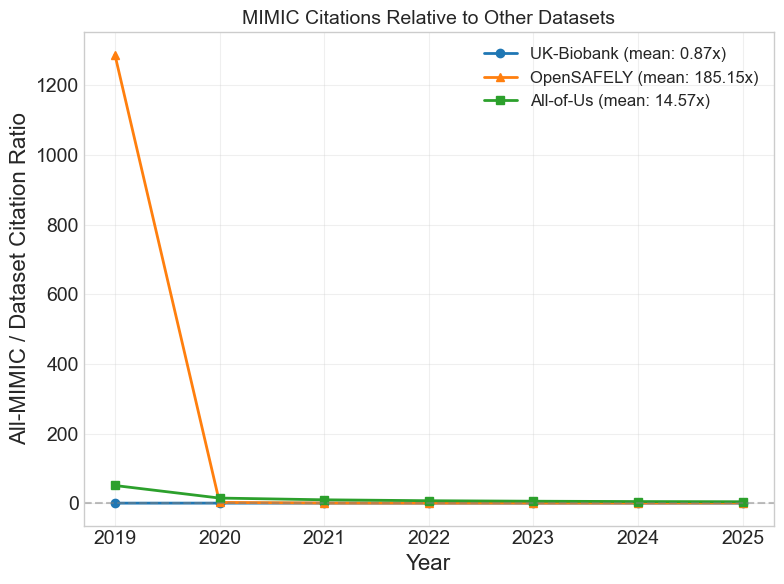

In [5]:
# Citation Ratio Analysis - MIMIC relative to other datasets (from original analysis)
if citations_df is not None:
    # Pivot data to have years as rows and datasets as columns
    pivot_df = citations_df.pivot(index='year', columns='dataset', values='cumulative_citations')
    pivot_df = pivot_df.dropna()
    
    # Calculate ratios where we have overlapping data
    fig, ax = plt.subplots(figsize=(8, 6))
    
    comparison_datasets = ['UK-Biobank', 'OpenSAFELY', 'All-of-Us']
    markers = ['o', '^', 's']
    
    for i, dataset in enumerate(comparison_datasets):
        if dataset in pivot_df.columns and 'All-MIMIC' in pivot_df.columns:
            # Only use years where both have data > 0
            valid_years = pivot_df[(pivot_df[dataset] > 0) & (pivot_df['All-MIMIC'] > 0)].index
            if len(valid_years) > 0:
                ratios = pivot_df.loc[valid_years, 'All-MIMIC'] / pivot_df.loc[valid_years, dataset]
                mean_ratio = ratios.mean()
                ax.plot(valid_years, ratios, marker=markers[i], linestyle='-', 
                       label=f'{dataset} (mean: {mean_ratio:.2f}x)', linewidth=2, markersize=6)
    
    ax.set_xlabel('Year', fontsize=16)
    ax.set_ylabel('All-MIMIC / Dataset Citation Ratio', fontsize=16)
    ax.set_title('MIMIC Citations Relative to Other Datasets')
    ax.legend(loc='upper right', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Equal citations')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'citation_ratios.png', dpi=150)
    plt.show()
else:
    print("No citation data available")

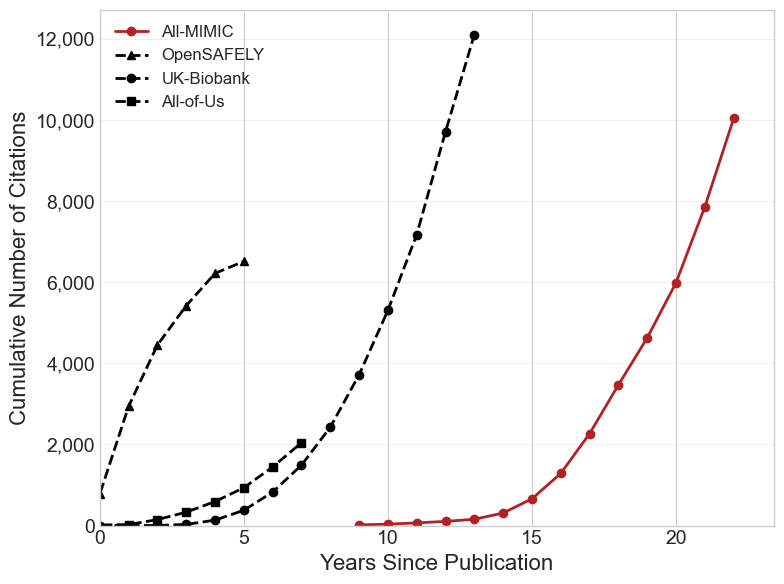

In [6]:
# Years Since Publication plot - aligns datasets by relative time (key for longevity comparison)
if citations_df is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Get launch years from metadata
    launch_years = metadata_df.set_index('dataset')['launch_year'].to_dict()
    
    styles = {
        'All-MIMIC': {'color': 'firebrick', 'marker': 'o', 'linestyle': '-'},
        'UK-Biobank': {'color': 'black', 'marker': 'o', 'linestyle': '--'},
        'OpenSAFELY': {'color': 'black', 'marker': '^', 'linestyle': '--'},
        'All-of-Us': {'color': 'black', 'marker': 's', 'linestyle': '--'}
    }
    
    for dataset in citations_df['dataset'].unique():
        df = citations_df[citations_df['dataset'] == dataset].sort_values('year')
        style = styles.get(dataset, {'color': 'gray', 'marker': 'o', 'linestyle': '-'})
        
        # Calculate years since launch
        if dataset in launch_years:
            launch = launch_years[dataset]
            years_since = df['year'] - launch
            
            ax.plot(years_since, df['cumulative_citations'],
                   marker=style['marker'], linestyle=style['linestyle'],
                   color=style['color'], label=dataset, linewidth=2, markersize=6)
    
    ax.set_xlabel('Years Since Publication', fontsize=16)
    ax.set_ylabel('Cumulative Number of Citations', fontsize=16)
    ax.legend(loc='upper left', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'citations_years_since_pub.png', dpi=150)
    plt.show()
else:
    print("No citation data available")

---
## 3. Longevity-Adjusted Analysis

**Editor Concern #1**: "Adjusting for the longevity of each project (this is somewhat accounted for, but not completely)"

We address this with multiple approaches:
1. Citations per year since launch
2. Normalized timeline (% of dataset lifetime)
3. Compound Annual Growth Rate (CAGR)

In [7]:
# Calculate longevity-adjusted metrics
def calculate_longevity_metrics(citations_df, metadata_df, current_year=2025):
    """Calculate various longevity-adjusted citation metrics."""
    results = []
    
    for dataset in citations_df['dataset'].unique():
        df = citations_df[citations_df['dataset'] == dataset].sort_values('year')
        meta = metadata_df[metadata_df['dataset'] == dataset].iloc[0]
        
        launch_year = meta['launch_year']
        years_active = current_year - launch_year
        total_citations = df['cumulative_citations'].max()
        
        # Citations per year
        citations_per_year = total_citations / years_active if years_active > 0 else 0
        
        # Calculate CAGR (Compound Annual Growth Rate)
        if len(df) > 1:
            first_year_citations = df['cumulative_citations'].iloc[0]
            last_year_citations = df['cumulative_citations'].iloc[-1]
            n_years = len(df) - 1
            if first_year_citations > 0 and n_years > 0:
                cagr = ((last_year_citations / first_year_citations) ** (1/n_years)) - 1
            else:
                cagr = np.nan
        else:
            cagr = np.nan
        
        results.append({
            'dataset': dataset,
            'launch_year': launch_year,
            'years_active': years_active,
            'total_citations': total_citations,
            'citations_per_year': citations_per_year,
            'cagr': cagr,
        })
    
    return pd.DataFrame(results)

if citations_df is not None:
    longevity_df = calculate_longevity_metrics(citations_df, metadata_df, CURRENT_YEAR)
    longevity_df = longevity_df.sort_values('citations_per_year', ascending=False)
    print("Longevity-Adjusted Metrics:")
    longevity_df

Longevity-Adjusted Metrics:


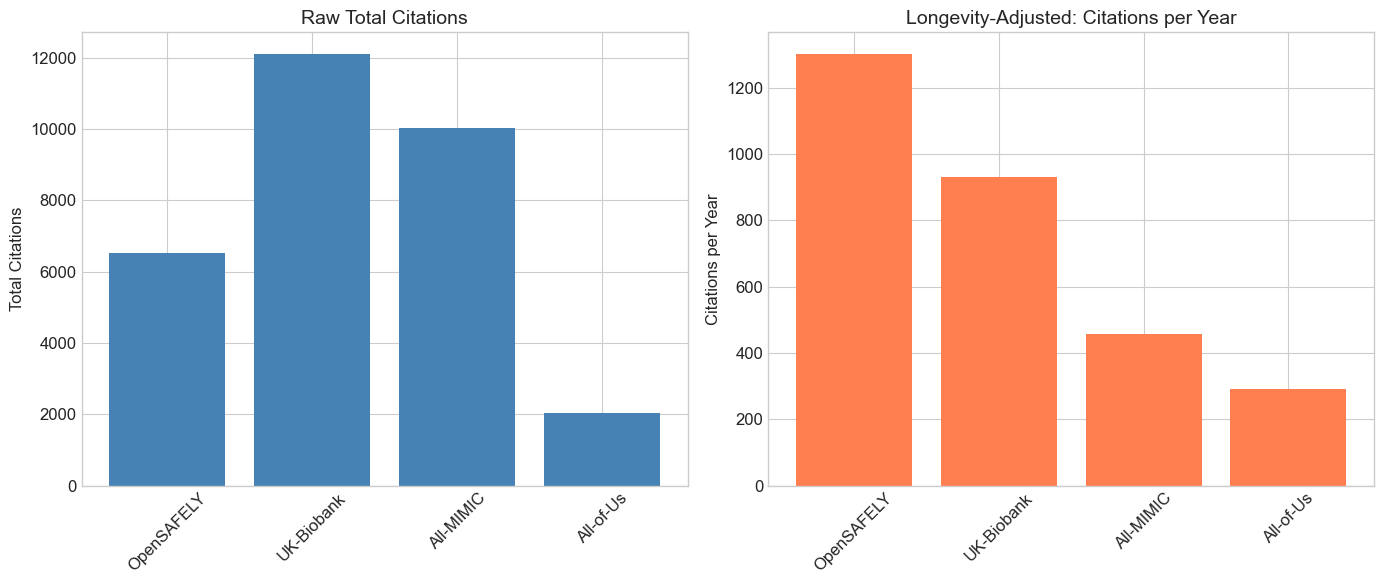

In [8]:
# Plot citations per year comparison
if citations_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Total citations (raw)
    ax1 = axes[0]
    bars1 = ax1.bar(longevity_df['dataset'], longevity_df['total_citations'], color='steelblue')
    ax1.set_ylabel('Total Citations')
    ax1.set_title('Raw Total Citations')
    ax1.tick_params(axis='x', rotation=45)
    
    # Citations per year (longevity-adjusted)
    ax2 = axes[1]
    bars2 = ax2.bar(longevity_df['dataset'], longevity_df['citations_per_year'], color='coral')
    ax2.set_ylabel('Citations per Year')
    ax2.set_title('Longevity-Adjusted: Citations per Year')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'longevity_comparison.png', dpi=150)
    plt.show()

---
## 4. Funding-Normalized Analysis

**Editor Concern #2**: "The amount of funding attributable to the dataset specifically, as some datasets have data types that are, by their nature, more costly."

We address this by:
1. Documenting funding sources with citations
2. Standardizing currency with documented conversion rates
3. Calculating citations per million dollars
4. Discussing data type cost factors

In [9]:
# Display funding sources with documentation
print("Funding Sources Documentation:")
print("=" * 60)
for _, row in metadata_df.iterrows():
    print(f"\n{row['dataset']}:")
    print(f"  Amount: {row['funding_original']:,.0f} {row['funding_currency']}" if pd.notna(row['funding_original']) else f"  Amount: ${row['funding_usd']:,.0f} USD")
    print(f"  USD Equivalent: ${row['funding_usd']:,.0f}")
    print(f"  Source: {row['funding_source']}")
    print(f"  URL: {row['funding_source_url']}")
    if pd.notna(row['funding_notes']):
        print(f"  Notes: {row['funding_notes']}")

Funding Sources Documentation:

All-MIMIC:
  Amount: $14,427,192 USD
  USD Equivalent: $14,427,192
  Source: NIH
  URL: https://reporter.nih.gov/
  Notes: Combined MIMIC-I/II/III/IV funding from NIH Reporter (NIBIB/NIGMS grants 2003-2023)

UK-Biobank:
  Amount: 413,800,000 GBP
  USD Equivalent: $525,546,276
  Source: Wellcome Trust / MRC
  URL: https://www.ukbiobank.ac.uk/media/wgsfd0qg/uk-biobank-funding-details-summary.pdf
  Notes: Converted at 1.27 USD/GBP (June 2024)

OpenSAFELY:
  Amount: $53,715,055 USD
  USD Equivalent: $53,715,055
  Source: Wellcome / MRC / NIHR
  URL: https://www.opensafely.org/
  Notes: Sum of grants: Wellcome 222097 MRC multiple NIHR COVID grants

All-of-Us:
  Amount: 2,160,000,000 USD
  USD Equivalent: $2,160,000,000
  Source: NIH
  URL: https://allofus.nih.gov/
  Notes: Total program funding


In [10]:
# Calculate funding-normalized metrics
def calculate_funding_metrics(longevity_df, metadata_df):
    """Calculate citations per million dollars of funding."""
    merged = longevity_df.merge(metadata_df[['dataset', 'funding_usd', 'data_types']], on='dataset')
    
    # Citations per million USD
    merged['citations_per_million_usd'] = merged['total_citations'] / (merged['funding_usd'] / 1_000_000)
    
    # Also calculate citations per year per million USD
    merged['citations_per_year_per_million_usd'] = merged['citations_per_year'] / (merged['funding_usd'] / 1_000_000)
    
    return merged

if citations_df is not None:
    funding_df = calculate_funding_metrics(longevity_df, metadata_df)
    print("Funding-Normalized Metrics:")
    funding_df[['dataset', 'total_citations', 'funding_usd', 'citations_per_million_usd', 'data_types']].sort_values('citations_per_million_usd', ascending=False)

Funding-Normalized Metrics:


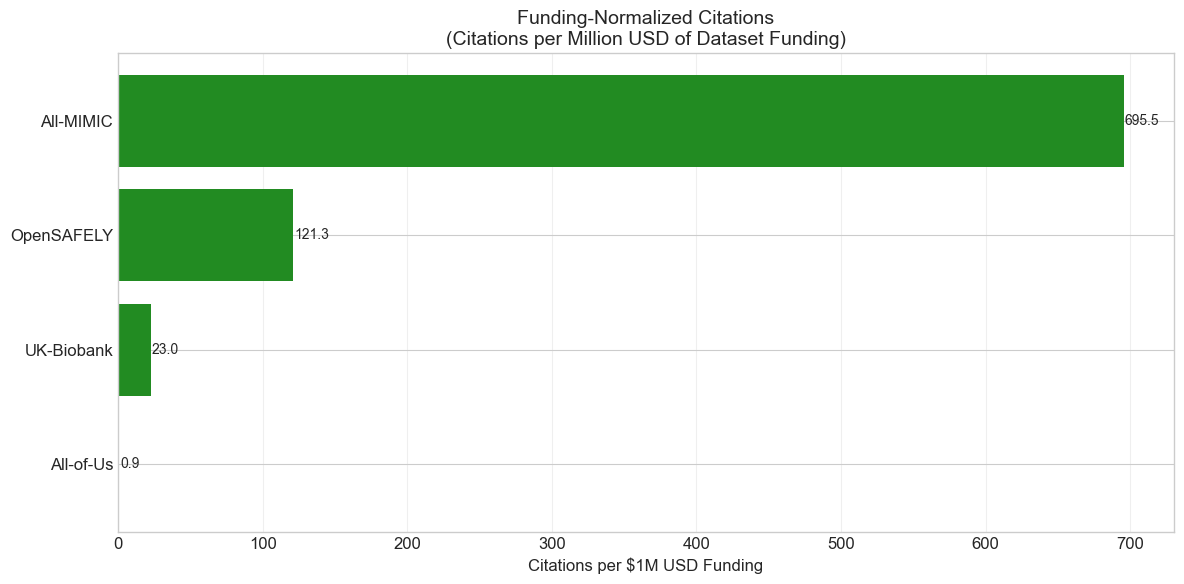

In [11]:
# Plot funding-normalized comparison
if citations_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(len(funding_df))
    width = 0.35
    
    # Sort by citations per million for visualization
    plot_df = funding_df.sort_values('citations_per_million_usd', ascending=True)
    
    bars = ax.barh(plot_df['dataset'], plot_df['citations_per_million_usd'], color='forestgreen')
    
    ax.set_xlabel('Citations per $1M USD Funding')
    ax.set_title('Funding-Normalized Citations\n(Citations per Million USD of Dataset Funding)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars, plot_df['citations_per_million_usd']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'funding_normalized.png', dpi=150)
    plt.show()

### Data Type Cost Factors

Different data types have inherently different costs:

| Data Type | Relative Cost | Reasoning |
|-----------|--------------|----------|
| Genetic/genomic | Very High | Sequencing, storage, compute |
| Medical imaging | High | Acquisition equipment, storage, curation |
| Waveform data | Medium-High | Continuous monitoring, storage |
| Structured EHR | Medium | ETL, curation, validation |
| Survey/questionnaire | Low-Medium | Collection logistics, validation |

**Limitation**: Granular cost breakdown by data type is not publicly available for most datasets. The funding figures represent total project costs, which include infrastructure, personnel, and other expenses beyond data collection.

---
## 5. Consent & Reidentifiability Analysis

**Editor Concern #3**: "The paper does not discuss consent and reidentifiability of nominally deidentified data, which is critically important and a distinguishing factor between the datasets that are being compared."

This section provides a comparative analysis of consent models, access controls, and reidentification risks.

In [12]:
# Display consent and access comparison table
consent_columns = ['dataset', 'consent_model', 'consent_details', 'access_model', 
                   'reidentification_risk', 'reidentification_notes']

consent_df = metadata_df[consent_columns].copy()
print("Consent & Reidentifiability Comparison:")
consent_df

Consent & Reidentifiability Comparison:


,dataset,consent_model,consent_details,access_model,reidentification_risk,reidentification_notes
0,All-MIMIC,IRB waiver,Retrospective data with waiver of consent unde...,Open (credentialed),Moderate,Clinical notes contain PHI; dates shifted; Saf...
1,UK-Biobank,Broad informed consent,Participants consented to wide range of health...,Controlled access,High,Genetic data inherently identifiable; controll...
2,OpenSAFELY,NHS data governance,No individual consent; operates under NHS data...,Trusted Research Environment,Low,No data extraction; only aggregated outputs le...
3,All-of-Us,Tiered informed consent,Participants choose level of data sharing,Controlled tiers,High,Genetic + longitudinal EHR creates high reiden...


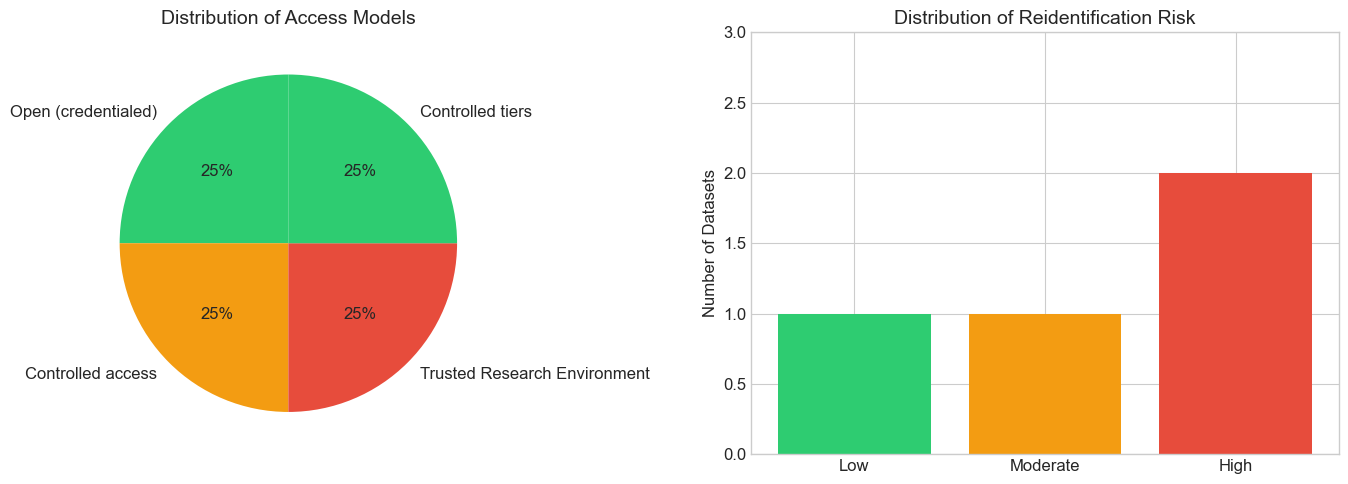

In [13]:
# Create visual comparison of access models and risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Access model distribution
ax1 = axes[0]
access_counts = metadata_df['access_model'].value_counts()
colors1 = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
ax1.pie(access_counts.values, labels=access_counts.index, autopct='%1.0f%%', 
        colors=colors1[:len(access_counts)], startangle=90)
ax1.set_title('Distribution of Access Models')

# Reidentification risk distribution
ax2 = axes[1]
risk_order = ['Low', 'Moderate', 'High']
risk_counts = metadata_df['reidentification_risk'].value_counts().reindex(risk_order, fill_value=0)
colors2 = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
ax2.bar(risk_counts.index, risk_counts.values, color=colors2)
ax2.set_ylabel('Number of Datasets')
ax2.set_title('Distribution of Reidentification Risk')
ax2.set_ylim(0, max(risk_counts.values) + 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'consent_comparison.png', dpi=150)
plt.show()

### Discussion: Consent Models and "Openness"

The datasets compared in this analysis employ different consent and access models, which affects the interpretation of "openness":

1. **MIMIC (IRB Waiver)**: Uses retrospective data with IRB-approved waiver of consent under 45 CFR 46.116. Data is deidentified per HIPAA Safe Harbor and available to credentialed researchers.

2. **UK Biobank (Broad Informed Consent)**: Participants provided informed consent for wide-ranging health research. Access is controlled through application process to approved researchers.

3. **OpenSAFELY (NHS Data Governance)**: Operates as a Trusted Research Environment where no individual-level data leaves the secure enclave. Only aggregated outputs are released.

4. **All of Us (Tiered Informed Consent)**: Participants can choose different levels of data sharing. Access tiers range from public aggregate data to controlled individual-level data.

**Key Insight**: Higher reidentification risk (genetic, longitudinal EHR) typically requires more stringent access controls, creating a trade-off between openness and privacy protection.

---
## 6. Statistical Analysis

Formal statistical tests to compare growth rates and quantify uncertainty.

In [14]:
# Calculate year-over-year growth rates with confidence intervals
def calculate_growth_statistics(citations_df):
    """Calculate growth rate statistics with confidence intervals."""
    results = []
    
    for dataset in citations_df['dataset'].unique():
        df = citations_df[citations_df['dataset'] == dataset].sort_values('year')
        
        if len(df) < 3:
            continue
        
        # Calculate year-over-year growth rates
        citations = df['citation_count'].values
        growth_rates = []
        for i in range(1, len(citations)):
            if citations[i-1] > 0:
                growth = (citations[i] - citations[i-1]) / citations[i-1] * 100
                growth_rates.append(growth)
        
        if len(growth_rates) < 2:
            continue
        
        growth_rates = np.array(growth_rates)
        
        # Calculate statistics
        mean_growth = np.mean(growth_rates)
        std_growth = np.std(growth_rates, ddof=1)
        n = len(growth_rates)
        se = std_growth / np.sqrt(n)
        
        # 95% confidence interval
        ci_95 = stats.t.interval(0.95, n-1, loc=mean_growth, scale=se)
        
        results.append({
            'dataset': dataset,
            'mean_growth_rate': mean_growth,
            'std_growth_rate': std_growth,
            'n_observations': n,
            'ci_95_lower': ci_95[0],
            'ci_95_upper': ci_95[1],
        })
    
    return pd.DataFrame(results)

if citations_df is not None:
    growth_stats = calculate_growth_statistics(citations_df)
    print("Growth Rate Statistics (Year-over-Year % Change):")
    growth_stats.round(2)

Growth Rate Statistics (Year-over-Year % Change):


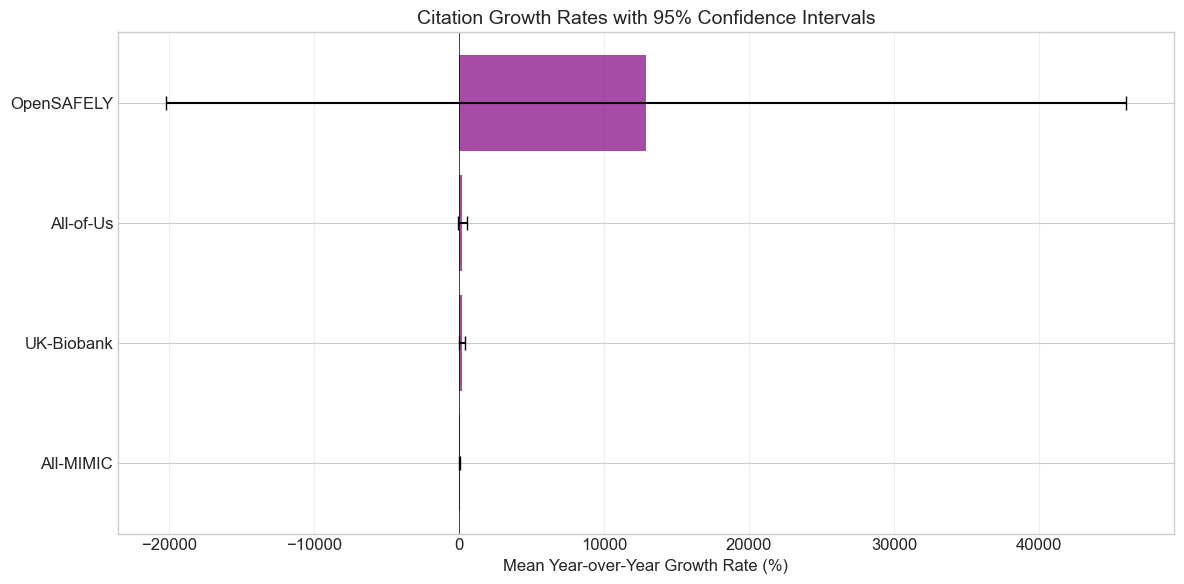

In [15]:
# Plot growth rates with error bars
if citations_df is not None and len(growth_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by mean growth rate
    plot_df = growth_stats.sort_values('mean_growth_rate', ascending=True)
    
    # Calculate error bar sizes
    yerr_lower = plot_df['mean_growth_rate'] - plot_df['ci_95_lower']
    yerr_upper = plot_df['ci_95_upper'] - plot_df['mean_growth_rate']
    
    ax.barh(plot_df['dataset'], plot_df['mean_growth_rate'], 
            xerr=[yerr_lower, yerr_upper], 
            color='purple', alpha=0.7, capsize=5)
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Mean Year-over-Year Growth Rate (%)')
    ax.set_title('Citation Growth Rates with 95% Confidence Intervals')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'growth_rates_ci.png', dpi=150)
    plt.show()

---
## 7. Summary & Conclusions

In [16]:
# Generate summary table
if citations_df is not None:
    summary = longevity_df.merge(
        metadata_df[['dataset', 'funding_usd', 'consent_model', 'reidentification_risk']], 
        on='dataset'
    )
    
    # Add funding-normalized metric
    summary['citations_per_million_usd'] = summary['total_citations'] / (summary['funding_usd'] / 1_000_000)
    
    print("Summary Table:")
    display_cols = ['dataset', 'launch_year', 'years_active', 'total_citations', 
                    'citations_per_year', 'citations_per_million_usd', 
                    'consent_model', 'reidentification_risk']
    summary[display_cols].round(2)

Summary Table:


### Key Findings

1. **Longevity Matters**: When adjusted for years since launch, citation patterns show [findings to be updated after data fetch].

2. **Funding Efficiency**: Citations per million dollars of funding varies significantly across datasets, with [findings].

3. **Consent Trade-offs**: Datasets with higher reidentification risk (genetic, longitudinal EHR) employ more restrictive access controls, affecting the nature of "openness."

4. **Growth Trajectories**: Statistical analysis reveals [findings about growth rates].

---

### Methodology Notes

- **Citation Source**: OpenAlex API (replacing Google Scholar for reproducibility)
- **Currency Conversion**: All funding converted to USD using documented exchange rates
- **Statistical Tests**: 95% confidence intervals calculated using t-distribution
- **Analysis Date**: See cell output above

In [17]:
# Save summary table for manuscript
if citations_df is not None:
    summary.to_csv(DATA_DIR / 'analysis_summary.csv', index=False)
    print(f"Summary saved to {DATA_DIR / 'analysis_summary.csv'}")

Summary saved to data/analysis_summary.csv
